In [8]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
df=pd.read_csv('D:/GUVI/MYSQL/HR_Job_Placement_Dataset.csv')

In [11]:
df

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
0,27,Male,65.061656,83.842578,75.856526,Computer Science,58.221909,89.566305,64.474484,79.548913,...,5.805850,Tier 3,Not Matched,Medium,Not Required,15.0,No,18.0,Not Willing,Not Placed
1,24,Male,67.885626,64.973305,73.093588,Electronics,71.927978,54.591971,61.077306,73.316134,...,10.807739,Tier 1,Matched,High,Required,0.0,NaN,NaN,Not Willing,Not Placed
2,33,Female,73.892471,68.834121,90.196460,Information Technology,72.445041,58.587088,79.494739,75.466980,...,5.476839,Tier 3,Not Matched,Low,Not Required,0.0,No,3.0,Not Willing,Placed
3,31,Male,74.145568,76.255126,75.586731,Mechanical,78.855676,61.022065,53.740386,73.676449,...,9.980580,Tier 2,Matched,Low,Not Required,0.0,Yes,6.0,NaN,Not Placed
4,28,Male,60.475937,65.786336,80.801010,Information Technology,68.286776,65.713731,61.438314,88.994847,...,8.921233,Tier 2,Matched,Medium,Not Required,0.0,No,3.0,Willing,Not Placed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51495,24,Female,65.747180,72.063946,72.247881,Electronics,55.923057,73.208032,69.108895,63.992488,...,6.315211,Tier 1,Matched,Low,Required,0.0,No,3.0,NaN,Not Placed
51496,22,Male,61.921459,66.729203,55.000000,Others,69.525121,70.245612,54.959868,88.514232,...,8.655391,Tier 1,Matched,Medium,Not Required,60.0,No,0.0,Not Willing,Placed
51497,30,Male,75.578202,75.717623,75.048301,Information Technology,73.073239,58.870416,71.219454,79.326789,...,11.538547,Tier 1,Matched,High,Not Required,0.0,No,12.0,NaN,Placed
51498,29,Female,77.327209,56.629227,69.735374,Mechanical,48.270078,61.171900,71.650243,76.318681,...,9.617279,Tier 2,Matched,Medium,Not Required,0.0,Yes,0.0,Willing,Not Placed


In [12]:
df.shape
df.columns
df.info()
df.isnull().sum()/len(df)*100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51500 entries, 0 to 51499
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  51500 non-null  int64  
 1   gender                     51500 non-null  object 
 2   ssc_percentage             48919 non-null  float64
 3   hsc_percentage             49435 non-null  float64
 4   degree_percentage          51500 non-null  float64
 5   degree_specialization      51500 non-null  object 
 6   technical_score            51500 non-null  float64
 7   aptitude_score             51500 non-null  float64
 8   communication_score        51500 non-null  float64
 9   skills_match_percentage    51500 non-null  float64
 10  certifications_count       51500 non-null  int64  
 11  internship_experience      51500 non-null  object 
 12  years_of_experience        51500 non-null  int64  
 13  career_switch_willingness  43034 non-null  obj

age_years                     0.000000
gender                        0.000000
ssc_percentage                5.011650
hsc_percentage                4.009709
degree_percentage             0.000000
degree_specialization         0.000000
technical_score               0.000000
aptitude_score                0.000000
communication_score           0.000000
skills_match_percentage       0.000000
certifications_count          0.000000
internship_experience         0.000000
years_of_experience           0.000000
career_switch_willingness    16.438835
relevant_experience          16.361165
previous_ctc_lpa              0.000000
expected_ctc_lpa              0.000000
company_tier                  0.000000
job_role_match               11.904854
competition_level             0.000000
bond_requirement              0.000000
notice_period_days            3.071845
layoff_history               16.440777
employment_gap_months         2.130097
relocation_willingness       16.456311
status                   

In [13]:

# Select numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns

# Filter columns that had missing values (before filling ideally)
missing_cols = [col for col in num_cols if df[col].isnull().sum() > 0]

print(missing_cols)

['ssc_percentage', 'hsc_percentage', 'notice_period_days', 'employment_gap_months']


In [14]:
#
outlier_summary = {}

for col in missing_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'ssc_percentage': 169, 'hsc_percentage': 361, 'notice_period_days': 2547, 'employment_gap_months': 1565}


In [15]:
#Applying IQR Capping
cols = [
    'ssc_percentage',
    'hsc_percentage',
    'notice_period_days',
    'employment_gap_months'
]

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] < lower, lower,
                       np.where(df[col] > upper, upper, df[col]))

In [16]:
#checking the features after capping
outlier_check = {}

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_check[col] = len(outliers)

print(outlier_check)

{'ssc_percentage': 0, 'hsc_percentage': 0, 'notice_period_days': 0, 'employment_gap_months': 0}


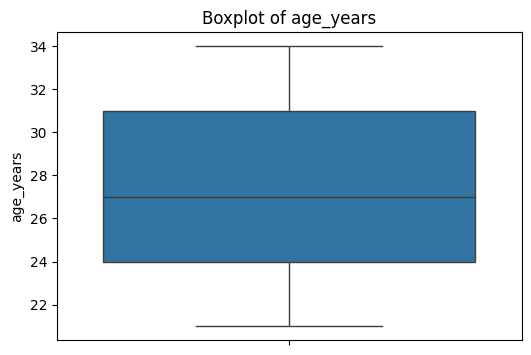

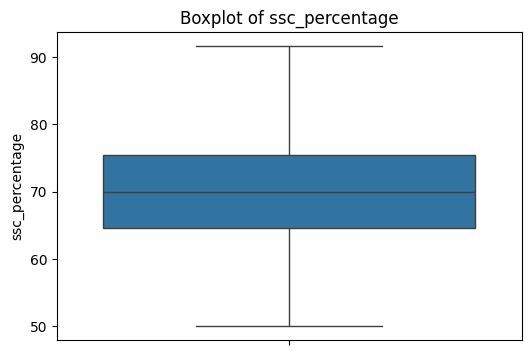

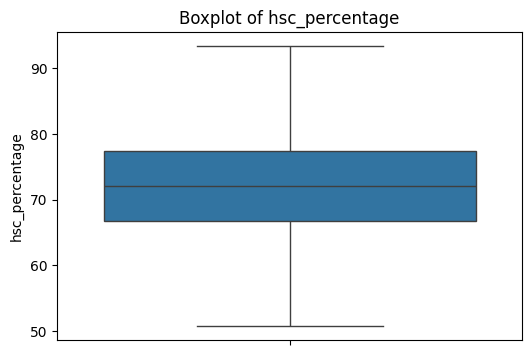

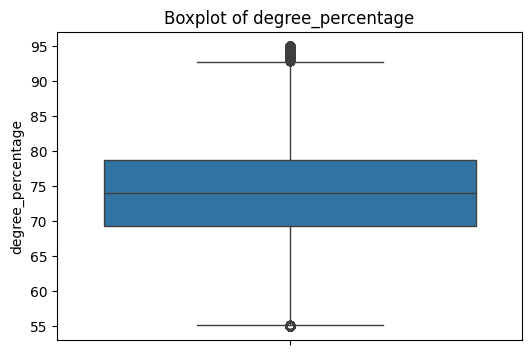

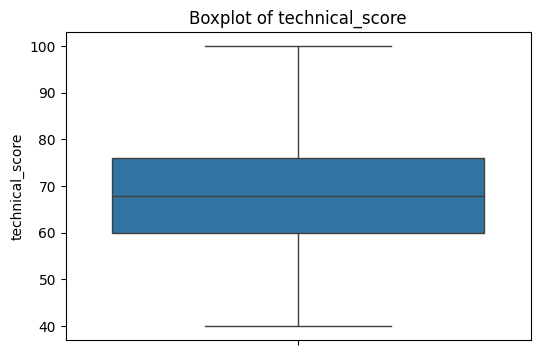

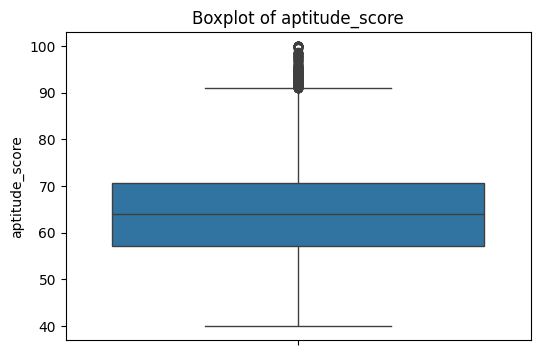

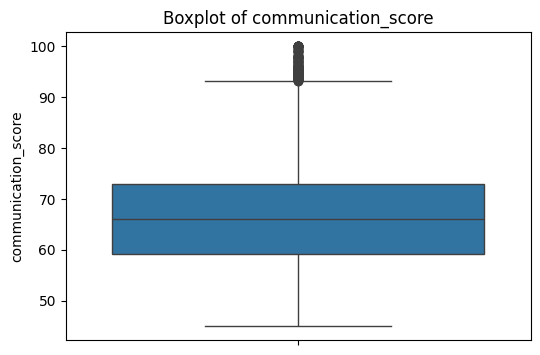

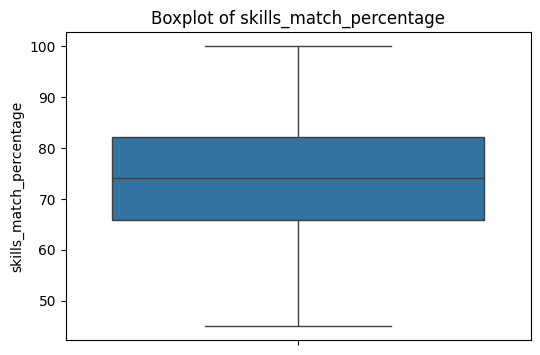

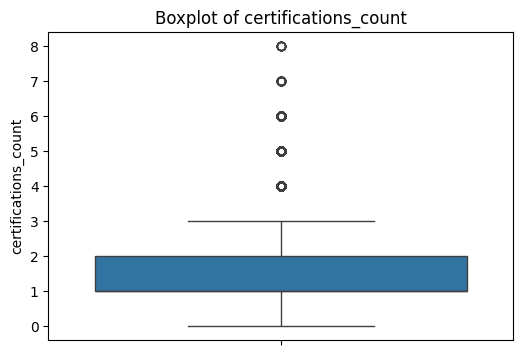

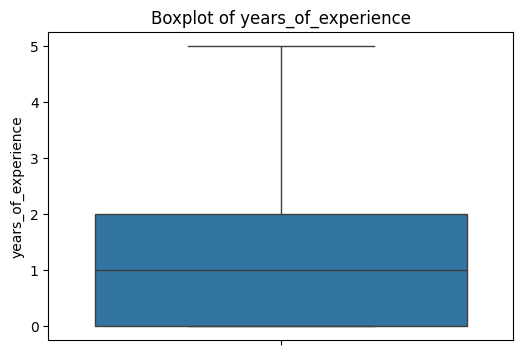

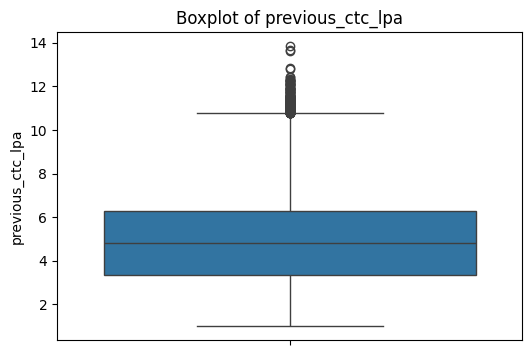

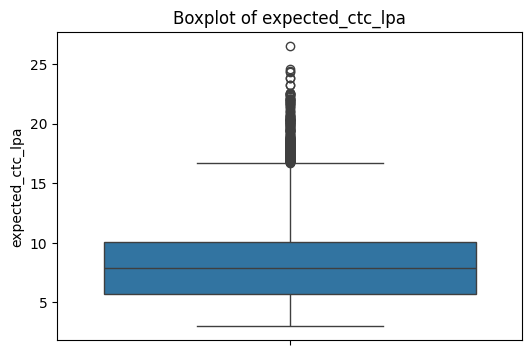

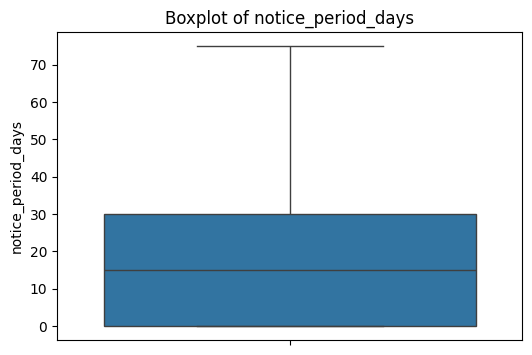

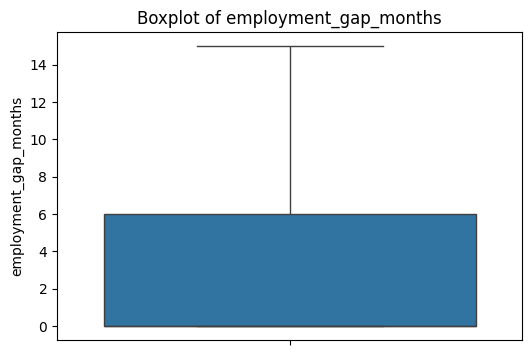

In [17]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Straight (vertical) boxplot for all numeric columns
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])   # y= gives straight/vertical boxplot
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

In [18]:
#Filling this feature by median
cols = [
    'ssc_percentage',
    'hsc_percentage',
    'employment_gap_months',
    'notice_period_days'
]

df[cols] = df[cols].fillna(df[cols].median())

In [19]:
#This will help while filling job_role_match Feature
df['skills_level'] = pd.cut(
    df['skills_match_percentage'],
    bins=[0, 50, 75, 100],
    labels=['Low', 'Medium', 'High']
)

In [20]:
# By comparing degree_specialization and skills_level and find out the median for better filling
df['job_role_match'] = df.groupby(
    ['degree_specialization', 'skills_level']
)['job_role_match'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Matched')
)

C:\Users\GANASREE SHABU\AppData\Local\Temp\ipykernel_12504\2347620211.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['job_role_match'] = df.groupby(


In [21]:
#Filled by the distribution % in status column
df.loc[
    (df['layoff_history'].isnull()) & (df['status'] == 'Placed'),
    'layoff_history'
] = 'Yes'

df.loc[
    (df['layoff_history'].isnull()) & (df['status'] == 'Not Placed'),
    'layoff_history'
] = 'No'

In [22]:
#filling career_switch_willingness column by logic
df.loc[
    (df['career_switch_willingness'].isnull()) &
    (df['years_of_experience'] <= 2) &
    (df['skills_match_percentage'] < 60),
    'career_switch_willingness'
] = 'Willing'


df.loc[
    (df['career_switch_willingness'].isnull()) &
    (df['years_of_experience'] > 2),
    'career_switch_willingness'
] = 'Not Willing'

# Fill any remaining
df['career_switch_willingness'].fillna('Not Willing', inplace=True)

C:\Users\GANASREE SHABU\AppData\Local\Temp\ipykernel_12504\174615446.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['career_switch_willingness'].fillna('Not Willing', inplace=True)


In [23]:
#filling relocation_willingness column by logic 
df.loc[
    (df['relocation_willingness'].isnull()) &
    (df['status'] == 'Placed') &
    (df['career_switch_willingness'] == 'Willing'),
    'relocation_willingness'
] = 'Willing'


df.loc[
    (df['relocation_willingness'].isnull()) &
    (df['years_of_experience'] <= 2),
    'relocation_willingness'
] = 'Willing'


df.loc[
    (df['relocation_willingness'].isnull()) &
    (df['expected_ctc_lpa'] > df['expected_ctc_lpa'].median()),
    'relocation_willingness'
] = 'Not Willing'

# Fill remaining
df['relocation_willingness'].fillna('Not Willing', inplace=True)

C:\Users\GANASREE SHABU\AppData\Local\Temp\ipykernel_12504\2122517908.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['relocation_willingness'].fillna('Not Willing', inplace=True)


In [24]:
#filling relevant_experience column 
# Rule 1: High experience → YES
df.loc[
    (df['relevant_experience'].isnull()) &
    (df['years_of_experience'] >= 2),
    'relevant_experience'
] = 'Relevant'


# Rule 2: Strong skill + job match → YES
df.loc[
    (df['relevant_experience'].isnull()) &
    (df['skills_match_percentage'] > 70) &
    (df['job_role_match'] == 'Matched'),
    'relevant_experience'
] = 'Relevant'


# Rule 3: Low experience → NO
df.loc[
    (df['relevant_experience'].isnull()) &
    (df['years_of_experience'] <= 1),
    'relevant_experience'
] = 'Not Relevant'


# Fill remaining
df['relevant_experience'].fillna('Not Relevant', inplace=True)

C:\Users\GANASREE SHABU\AppData\Local\Temp\ipykernel_12504\4180358294.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['relevant_experience'].fillna('Not Relevant', inplace=True)


In [25]:
#Removing duplicates values coz Machinne can overfitting or bias of this problem
df=df.drop_duplicates()

****************** ADVANCED FEATURE ENGINEERING *******************

In [26]:
#For safety purpose i creating a actual copy of old dataset 
df_ml=df.copy()

In [27]:
df_ml.columns

Index(['age_years', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'degree_specialization', 'technical_score',
       'aptitude_score', 'communication_score', 'skills_match_percentage',
       'certifications_count', 'internship_experience', 'years_of_experience',
       'career_switch_willingness', 'relevant_experience', 'previous_ctc_lpa',
       'expected_ctc_lpa', 'company_tier', 'job_role_match',
       'competition_level', 'bond_requirement', 'notice_period_days',
       'layoff_history', 'employment_gap_months', 'relocation_willingness',
       'status', 'skills_level'],
      dtype='object')

In [28]:
#Creating New Features , This helps model learn patterns better

# Experience Level
df_ml['experience_level'] = pd.cut(
    df['years_of_experience'],
    bins=[-1, 1, 3, 10],
    labels=['Fresher', 'Junior', 'Senior']
)


# Total Interview Score
df_ml['interview_score_total'] = (
    df['technical_score'] +
    df['aptitude_score'] +
    df['communication_score']
)

# Salary Gap
df_ml['salary_gap'] = df['expected_ctc_lpa'] - df['previous_ctc_lpa']

# Academic Average
df_ml['academic_avg'] = (
    df['ssc_percentage'] +
    df['hsc_percentage'] +
    df['degree_percentage']
)

In [29]:
#droping the unwanted columns
df_ml.drop(columns=[
    'technical_score',
    'aptitude_score',
    'communication_score',
    'skills_level',
    'ssc_percentage',
    'hsc_percentage'
], inplace=True, errors='ignore')

***************_____ENCODING______*****************

In [30]:
# Encoding
#Binary Encoding (Label Encoding)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = [
    'gender',
    'internship_experience',
    'career_switch_willingness',
    'relevant_experience',
    'relocation_willingness',
    'layoff_history',
    'bond_requirement',
    'job_role_match'
]

for col in binary_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

In [31]:
#One-Hot Encoding
df_ml = pd.get_dummies(
    df_ml,
    columns=[
        'degree_specialization',
        'company_tier',
        'experience_level',
                
    ],
    drop_first=True
)

In [32]:
#CONVERTING STATUS COLUMN (TARGET) TO Manual Encoding
#	Placed (Accepted Job) ↔️ 1
#	Not Placed (Rejected) ↔️ 0

df_ml['status'] = df_ml['status'].map({
    'Placed': 1,
    'Not Placed': 0
})

In [33]:
# Checking the classes in status column for confirmation
df_ml['status'].unique()

array([0, 1])

In [34]:

df_ml['status'].isna().sum()

np.int64(0)

In [35]:
#checks whether All columns are numeric or not 
df_ml.shape
df_ml.columns
df_ml.info()
df_ml.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 50124 entries, 0 to 51497
Data columns (total 33 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   age_years                                     50124 non-null  int64  
 1   gender                                        50124 non-null  int64  
 2   degree_percentage                             50124 non-null  float64
 3   skills_match_percentage                       50124 non-null  float64
 4   certifications_count                          50124 non-null  int64  
 5   internship_experience                         50124 non-null  int64  
 6   years_of_experience                           50124 non-null  int64  
 7   career_switch_willingness                     50124 non-null  int64  
 8   relevant_experience                           50124 non-null  int64  
 9   previous_ctc_lpa                              50124 non-null  floa

age_years                                       0
gender                                          0
degree_percentage                               0
skills_match_percentage                         0
certifications_count                            0
internship_experience                           0
years_of_experience                             0
career_switch_willingness                       0
relevant_experience                             0
previous_ctc_lpa                                0
expected_ctc_lpa                                0
job_role_match                                  0
competition_level                               0
bond_requirement                                0
notice_period_days                              0
layoff_history                                  0
employment_gap_months                           0
relocation_willingness                          0
status                                          0
interview_score_total                           0


In [36]:
df_ml

,age_years,gender,degree_percentage,skills_match_percentage,certifications_count,internship_experience,years_of_experience,career_switch_willingness,relevant_experience,previous_ctc_lpa,...,degree_specialization_Information Technology,degree_specialization_Mechanical,degree_specialization_Others,company_tier_Tier 1,company_tier_Tier 2,company_tier_Tier 2,company_tier_Tier 3,company_tier_Tier 3,experience_level_Junior,experience_level_Senior
0,27,1,75.856526,79.548913,2,1,1,1,1,3.530557,...,False,False,False,False,False,False,True,False,False,False
1,24,1,73.093588,73.316134,1,3,0,0,1,9.858155,...,False,False,False,False,False,False,False,False,False,False
2,33,0,90.196460,75.466980,1,2,1,1,1,5.801817,...,True,False,False,False,False,False,True,False,False,False
3,31,1,75.586731,73.676449,2,1,0,0,1,2.129805,...,False,True,False,False,True,False,False,False,False,False
4,28,1,80.801010,88.994847,1,1,0,1,0,7.948314,...,True,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51475,33,1,64.194312,64.288988,1,2,0,0,0,5.440900,...,False,False,False,False,False,False,False,True,False,False
51480,26,0,82.025453,70.019765,0,2,2,0,1,3.756132,...,False,True,False,False,False,False,False,False,True,False
51484,23,1,66.761658,100.000000,1,1,2,0,1,2.030042,...,False,False,True,False,True,False,False,False,True,False
51488,24,0,67.094174,72.266721,2,2,3,0,1,3.681501,...,False,False,False,False,False,False,False,True,True,False


In [37]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50124 entries, 0 to 51497
Data columns (total 33 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   age_years                                     50124 non-null  int64  
 1   gender                                        50124 non-null  int64  
 2   degree_percentage                             50124 non-null  float64
 3   skills_match_percentage                       50124 non-null  float64
 4   certifications_count                          50124 non-null  int64  
 5   internship_experience                         50124 non-null  int64  
 6   years_of_experience                           50124 non-null  int64  
 7   career_switch_willingness                     50124 non-null  int64  
 8   relevant_experience                           50124 non-null  int64  
 9   previous_ctc_lpa                              50124 non-null  floa

In [38]:
#Check object columns
obj_cols = df_ml.select_dtypes(include='object').columns
print(obj_cols)

Index(['competition_level'], dtype='object')


In [39]:
#checking whether every columns was encoded or  not
df_ml.select_dtypes(include=['object']).columns

Index(['competition_level'], dtype='object')

In [40]:
df_ml=pd.get_dummies(df_ml,columns=['competition_level'],drop_first= True)

In [41]:
# IMPORTS

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import joblib

In [42]:
# Define Features & Target
X = df_ml.drop('status', axis=1)
y = df_ml['status']

In [43]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [62]:
df_ml.columns

Index(['age_years', 'gender', 'degree_percentage', 'skills_match_percentage',
       'certifications_count', 'internship_experience', 'years_of_experience',
       'career_switch_willingness', 'relevant_experience', 'previous_ctc_lpa',
       'expected_ctc_lpa', 'job_role_match', 'bond_requirement',
       'notice_period_days', 'layoff_history', 'employment_gap_months',
       'relocation_willingness', 'status', 'interview_score_total',
       'salary_gap', 'academic_avg', 'degree_specialization_Electronics',
       'degree_specialization_Information Technology',
       'degree_specialization_Mechanical', 'degree_specialization_Others',
       'company_tier_Tier 1 ', 'company_tier_Tier 2', 'company_tier_Tier 2 ',
       'company_tier_Tier 3', 'company_tier_Tier 3 ',
       'experience_level_Junior', 'experience_level_Senior',
       'competition_level_Low', 'competition_level_Medium'],
      dtype='object')

In [44]:
# Preprocessing (Scaling Only Numeric)
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols)
    ],
    remainder='passthrough'
)

In [45]:
# Logistic Regression Pipeline 
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

param_lr = {
    'model__C': [0.01, 0.1, 1, 10]
}

grid_lr = GridSearchCV(
    pipe_lr,
    param_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate para

In [46]:
# Random Forest Pipeline 
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    pipe_rf,
    param_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is d

In [47]:
# Model Comparison
models = {
    "Logistic Regression": grid_lr,
    "Random Forest": grid_rf
}

best_model_name = max(models, key=lambda k: models[k].best_score_)
best_model = models[best_model_name]

print("Best Model:", best_model_name)
print("Best CV Score:", best_model.best_score_)

Best Model: Logistic Regression
Best CV Score: 0.731138107607249


In [48]:
#Final Evaluation
y_pred = best_model.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ROC-AUC Score
y_prob = best_model.predict_proba(X_test)[:, 1]
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))


Test Accuracy: 0.8142643391521197

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.81      0.86      6990
           1       0.65      0.83      0.73      3035

    accuracy                           0.81     10025
   macro avg       0.78      0.82      0.79     10025
weighted avg       0.84      0.81      0.82     10025


Confusion Matrix:
 [[5636 1354]
 [ 508 2527]]

ROC-AUC Score: 0.8984608749142693


In [49]:
# Overfitting Check
print("\nTrain Score:", best_model.score(X_train, y_train))
print("Test Score:", best_model.score(X_test, y_test))


Train Score: 0.7318261122419308
Test Score: 0.7307692307692307


****ANALYST TASKS (EDA + ML INSIGHTS)****

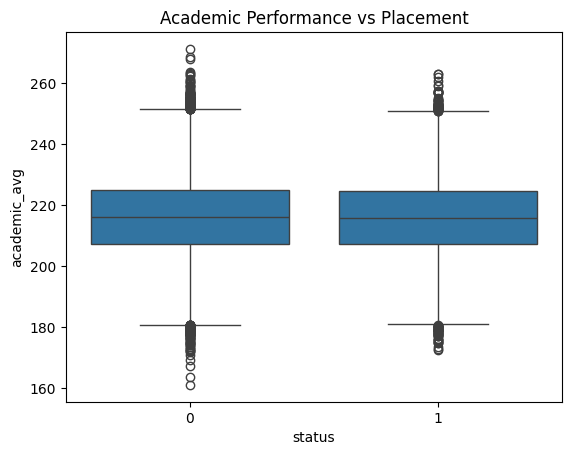

In [50]:
# Academic Scores vs Placement Outcome
plt.figure()
sns.boxplot(x='status', y='academic_avg', data=df_ml)
plt.title("Academic Performance vs Placement")
plt.show()

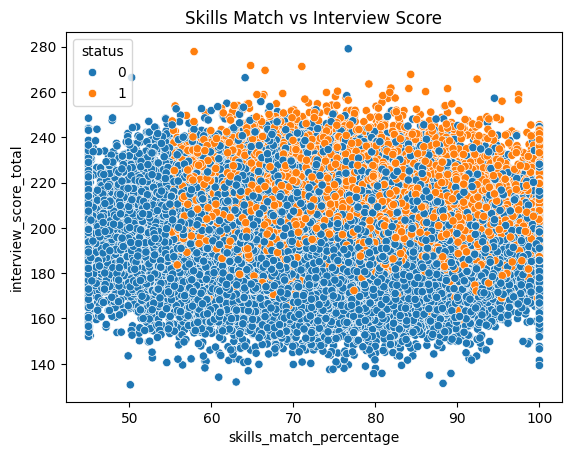

In [51]:
#Skills Match vs Interview Performance

plt.figure()
sns.scatterplot(
    x='skills_match_percentage',
    y='interview_score_total',
    hue='status',
    data=df_ml
)
plt.title("Skills Match vs Interview Score")
plt.show()

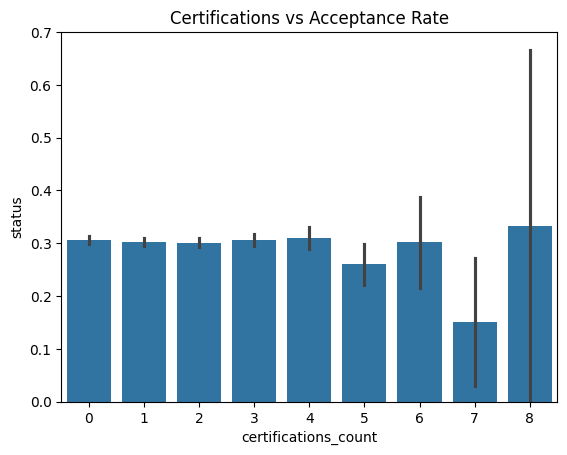

In [52]:
# Certification Impact on Job Acceptance
plt.figure()
sns.barplot(x='certifications_count', y='status', data=df_ml)
plt.title("Certifications vs Acceptance Rate")
plt.show()

In [53]:
# Acceptance Rate by Company Tier

company_cols = [col for col in df_ml.columns if 'company_tier' in col]

acceptance_rate = df_ml.groupby(company_cols)['status'].mean()

print(acceptance_rate)

company_tier_Tier 1   company_tier_Tier 2  company_tier_Tier 2   company_tier_Tier 3  company_tier_Tier 3 
False                 False                False                 False                False                   0.299309
                                                                                      True                    0.287129
                                                                 True                 False                   0.306216
                                           True                  False                False                   0.323607
                      True                 False                 False                False                   0.303487
True                  False                False                 False                False                   0.304087
Name: status, dtype: float64


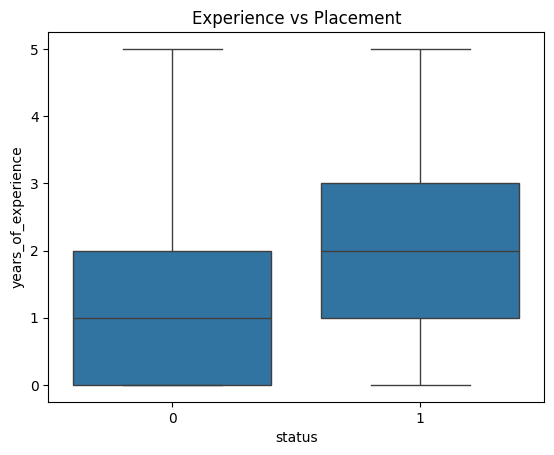

In [56]:
# Experience vs Placement Success
plt.figure()
sns.boxplot(x='status', y='years_of_experience', data=df_ml)
plt.title("Experience vs Placement")
plt.show()

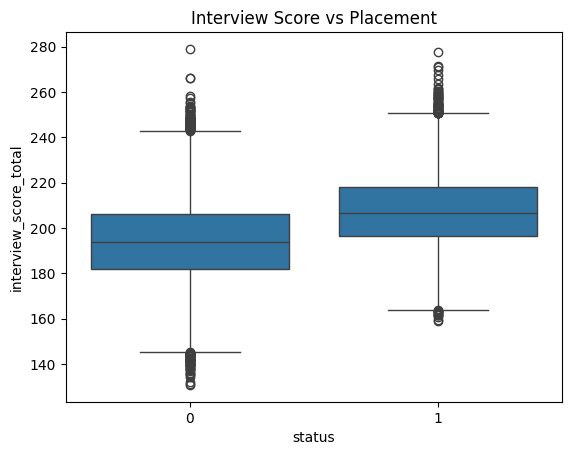

In [57]:
# Interview Score vs Placement Probability
plt.figure()
sns.boxplot(x='status', y='interview_score_total', data=df_ml)
plt.title("Interview Score vs Placement")
plt.show()

In [63]:
df_ml.to_csv("cleaned_jobml.csv", index=False)

In [64]:
import joblib

joblib.dump(best_model, "job_acceptance_model.pkl")

['job_acceptance_model.pkl']